In [1]:
#we want to build a network of 1 layer where it contains 3 neurons and 4 inputs and every input is connected to every other neuron
#and there is a bias associated with each neuron in pure python
inputs=[0.4,0.6,-0.8,0.7]
weights=[[0.4,0.6,0.9,0.7],
         [0.7,0.1,-0.5,0.7],
         [0.6,0.7,0.9,-1.6]]
bias=[0.7,0.6,0.7]
output=[]
for neuron_weights,neuron_bias in zip(weights,bias):
    neuron_output=0
    for weight,input in zip(neuron_weights,inputs):
        neuron_output+=weight*input
    neuron_output+=neuron_bias
    output.append(neuron_output)
print(output)


[0.9899999999999998, 1.83, -0.4800000000000002]


In [2]:
#now we will try to see the beauty of numpy in doing all these 
import numpy as np
inputs=[0.4,0.6,-0.8,0.7]
weights=[[0.4,0.6,0.9,0.7],
         [0.7,0.1,-0.5,0.7],
         [0.6,0.7,0.9,-1.6]]
bias=[0.7,0.6,0.7]
inputs1=[[0.5,0.7,0.3,-0.7],
         [0.7,0.2,0.5,0.9],
         [0.3,0.6,0.7,0.8]]
#vector to vector multiplication single neuron
weights1=[0.5,0.7,0.8,0.2]
bias1=0.7
output1=np.dot(inputs,weights1)+bias1
print(output1)
#vector to matrix single layer of neurons with single input
output2=np.dot(weights,inputs)+bias
print(output2)
#matrix to matrix multiplication batch of inputs to singlr layer network
output3=np.dot(np.array(inputs1),np.array(weights).T)+bias
print(output3)


0.8199999999999998
[ 0.99  1.83 -0.48]
[[1.1  0.38 2.88]
 [2.18 1.49 0.27]
 [2.37 1.08 0.65]]


# NumPy Dimension Guide: Neural Network Dot Products & Broadcasting

This guide summarizes how shapes, matrix multiplications (`np.dot`), and addition (biases) align when building neural network layers in NumPy.

---

## Scenario 1: Single Input Vector (Matrix-Vector Multiplication)

When passing a flat 1D array as the second argument to `np.dot()`, NumPy treats it as a column vector for multiplication, but outputs a flat 1D array.

### 1. Shape Breakdown
* **Weights (`W`):** `(3, 4)` &rarr; 3 Neurons, 4 Features each.
* **Inputs (`x`):** `(4,)` &rarr; Flat 1D array containing 4 features.
* **Biases (`b`):** `(3,)` &rarr; Flat 1D array containing 3 bias values.

### 2. Under the Hood Dot Product Execution
```text
  Weights Matrix       Implicit Column Vector      Output Vector (1D)
    (3 x 4)                  (4 x 1)                    (3,)
[ .  .  .  . ]             [ input_1 ]              [ neuron_1_dot ]
[ .  .  .  . ]     X       [ input_2 ]      =       [ neuron_2_dot ]
[ .  .  .  . ]             [ input_3 ]              [ neuron_3_dot ]
                           [ input_4 ]
[ dot_1,  dot_2,  dot_3 ]      <- Shape (3,)
+ [ bias_1, bias_2, bias_3 ]      <- Shape (3,)
----------------------------
  [ out_1,  out_2,  out_3 ]      <- Shape (3,)
Layer Outputs (3x3)              Stretched Biases (3x3)
  [ Out11  Out12  Out13 ]         [ Bias1  Bias2  Bias3 ]  <- Added to Row 1
  [ Out21  Out22  Out23 ]    +    [ Bias1  Bias2  Bias3 ]  <- Added to Row 2
  [ Out31  Out32  Out33 ]         [ Bias1  Bias2  Bias3 ]  <- Added to Row 3


In [3]:
#now we will try to code multiple layers of neural networks where output of one layer will be iput to next one.
weights1=[[0.4,0.6,0.9,0.7],
         [0.7,0.1,-0.5,0.7],
         [0.6,0.7,0.9,-1.6]]
bias1=[0.7,0.6,0.7]
bias2=[0.4,0.6,0.7]
weights2=[[0.5,0.7,0.3],
         [0.7,0.2,0.5],
         [0.3,0.6,0.7]]
inputs=[[0.5,0.7,0.3,-0.7],
         [0.7,0.2,0.5,0.9],
         [0.3,0.6,0.7,0.8]]
#for the rows to become batch samples we have to multiply it with inputs with transpose of weights.
layer1_output=np.dot(inputs,np.array(weights1).T)+bias1
final_output=np.dot(layer1_output,np.array(weights2).T)+bias2
print(final_output)


[[2.08  2.886 3.274]
 [2.614 2.559 2.437]
 [2.536 2.8   2.514]]


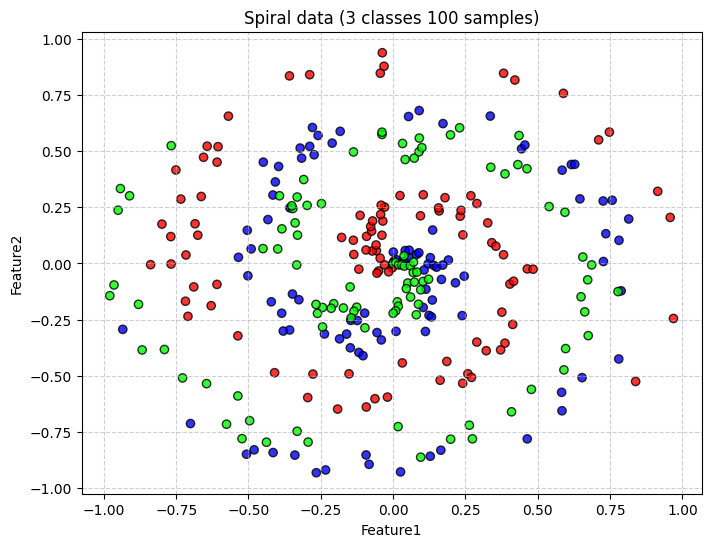

In [4]:
#now we are going to deal with spiral data where we need to for dense neural netwroks 
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import spiral_data
nnfs.init()
X,y=spiral_data(samples=100,classes=3)
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='brg',edgecolors='k',alpha=0.8)
plt.title("Spiral data (3 classes 100 samples)")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.grid(True,linestyle="--",alpha=0.6)
plt.show()



In [5]:
#we are going to implement a dense class which can try to handle this non linear data
class Layer_Dense:
    def __init__(self,n_inputs,n_neurons):
        self.weights=0.01*np.random.randn(n_inputs,n_neurons)
        #example if we have 3 neurons and 2 inputs then we will generate matrix of random values
        #of size 2*3 where one column contains weights for one neuron
        self.biases=np.zeros((1,n_neurons))
        #here we are generating a bias size 1*3
    def forward(self,inputs):
        self.inputs=inputs
        self.output=np.dot(inputs,self.weights)+self.biases
        return self.output
    #for getting these three equations we need to listen to the lectures 
    #here dvalues are derivative of loss with respect to output
    #and next we will get the derivative of output with respect to weight which automatically results in input
    #same opposite while doing for inputs also 
    def backward(self,dvalues):
        self.dweights=np.dot(self.inputs.T,dvalues)
        self.dbiases=np.sum(dvalues,axis=0,keepdims=True)
        self.dinputs=np.dot(dvalues,self.weights.T)
X,y=spiral_data(samples=100,classes=3)
dense1=Layer_Dense(2,3)
dense1.forward(X)
print(dense1.output[:5])
#in the output every row represents the output of each neuron for that batch of data
        


[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.11171044e-04 -5.11007493e-05 -1.12099799e-04]
 [ 2.99257295e-06 -2.69126613e-04 -1.45165104e-04]
 [ 8.95101766e-05 -4.30442247e-04 -1.68079801e-04]
 [-3.49893759e-04 -3.07208364e-04 -4.33002861e-04]]


# NumPy Reference: Absolute Rules of Broadcasting & Axis Operations

---

## 1. The 2 Rules of Broadcasting

When performing any element-wise operation (addition, subtraction, multiplication, etc.) between two arrays, NumPy evaluates their shape compatibility using these two conditions:

* **Right-to-Left Alignment:** NumPy aligns and compares the shape tuples starting from the **rightmost dimension** (the trailing dimension) and works its way backward to the left.
* **Compatibility Criteria:** For each paired dimension checked, the two sizes are compatible **only if**:
  1. The dimensions are **equal** in size, OR
  2. One of the dimensions is **exactly 1**.

> **Note on unequal lengths:** If one array has fewer dimensions than the other, NumPy implicitly pads the shorter shape tuple on the **left side** with dimensions of size **1**.

*If any dimension fails these criteria during the right-to-left scan, NumPy immediately halts and throws a `ValueError`.*

---

## 2. The Exact Rules of Axis Operations

When using an aggregation function (like `np.sum()`, `np.mean()`, or `np.max()`), the `axis` parameter dictates which dimension is targeted and completely eliminated from the output shape.



### Axis 0
* **Direction:** Along the vertical columns (moving down the rows).
* **Action:** Collapses the **row dimension** (index 0 of the shape tuple).
* **Result:** The row dimension is deleted. The output is a 1D array containing a single calculated value for each original column.

### Axis 1
* **Direction:** Along the horizontal rows (moving across the columns).
* **Action:** Collapses the **column dimension** (index 1 of the shape tuple).
* **Result:** The column dimension is deleted. The output is a 1D array containing a single calculated value for each original row.

# How Neural Networks Create a Triangle Pattern Using ReLU

A single standard ReLU function can only create a straight line that slopes upward forever. To capture an isolated shape like a **triangle pattern**, a neural network must combine multiple shifted and flipped ReLU functions.

---

## 1. The Components Explained

### Equation 1 ($i_1$): The Upward Foundation
$$i_1 = \text{ReLU}(X) = \max(0, X)$$

* **Before $X = 0$:** The output is completely flat at `0`.
* **After $X = 0$:** The output shoots **upward** at a constant $+1$ slope.
* **Purpose:** This forms the left-hand rising side of the triangle.

### Equation 2 ($i_2$): The Counter-Balance Control
$$i_2 = 2 - \text{ReLU}(X - 2)$$

This component uses three transformations to control the right side of the peak:
1. `ReLU(X - 2)` &rarr; Delays the activation so it stays flat at `0` until it reaches $X = 2$.
2. `- ReLU(X - 2)` &rarr; Flips the slope upside down, forcing it to shoot **downward** after $X = 2$.
3. `2 - ReLU(X - 2)` &rarr; Lifts the entire graph up by `2` units.

* **Result for $i_2$:** Before $X = 2$, it outputs a flat constant value of **exactly 2**. After $X = 2$, it drops downward.

---

## 2. Step-by-Step Combination ($i_1 + i_2$)

When the network adds these two streams together, it creates three distinct structural zones:

### Zone 1: The Rising Slope (From $X = 0$ to $X = 2$)
* **$i_1$:** Slopes upward from `0` to `2`.
* **$i_2$:** Is a completely flat constant of `2`.
* **Combination ($i_1 + i_2$):** Adding the flat `2` simply shifts the rising slope upward. 
* **Visual Result:** A clean, ascending line forming the **left side** of the triangle.

### Zone 2: The Peak (At $X = 2$)
* **$i_1$:** Reaches a value of `2`.
* **$i_2$:** Is at a value of `2`.
* **Combination ($i_1 + i_2$):** $2 + 2 = 4$.
* **Visual Result:** This single point forms the maximum height (the **absolute peak**) of the triangle.

### Zone 3: The Falling Slope (Beyond $X = 2$)
* **$i_1$:** Continues to head upward ($+1$ slope).
* **$i_2$:** Actively shoots downward ($-1$ slope).
* **Combination ($i_1 + i_2$):** The $+1$ and $-1$ slopes pull against each other. Because $i_2$ is falling from a shifted starting value, the combination stops the upward climb and forces the total sum to bend sharply back toward the ground.
* **Visual Result:** A clean, descending line forming the **right side** of the triangle.

---

## 3. Core Concept Summary



By routing data through these two neurons, the network effectively executes a logic gate:
* **Neuron 1 ($i_1$)** says: *"Start climbing at 0."*
* **Neuron 2 ($i_2$)** says: *"Once you hit position 2, pull down harder than the climb."*

The sum of these two opposing instructions isolates and traps data perfectly inside a **triangle pattern**.

In [6]:
#we are going to implement ReLU activation function using numpy
class Activation_ReLU:
    def forward(self,inputs):
        self.output=np.maximum(0,inputs)
        return self.output
#we are going to implement softmax activation function for the output layer in order to get probabilities 
class Activation_Softmax:
    def forward(self,inputs):
        expvalues=np.exp(inputs-np.max(inputs,axis=1,keepdims=True))
        #converting all the values in the output matrix into exponentials by subtracting the max term 
        #in order to avoid large numbers
        probabilities=expvalues/np.sum(expvalues,axis=1,keepdims=True)
        #dividing it with the sum to get probabilities
        self.output=probabilities
        return self.output


In [7]:
#trying to predict the actual labels of spiral data 
#one forward pass in neural network
X,y=spiral_data(samples=100,classes=3)
layer1=Layer_Dense(2,3)
layer2=Layer_Dense(3,3)
activation1=Activation_ReLU()
activation2=Activation_Softmax()
output_layer1=layer1.forward(X)
layer1_activation=activation1.forward(output_layer1)
output_layer2=layer2.forward(layer1_activation)
layer2_activation=activation2.forward(output_layer2)
print(layer2_activation[:5])




[[0.33333334 0.33333334 0.33333334]
 [0.33333418 0.33333272 0.33333308]
 [0.3333347  0.33333236 0.33333296]
 [0.33333558 0.33333167 0.33333272]
 [0.3333367  0.3333308  0.3333324 ]]


# NumPy Reference: Advanced Indexing, Entropy, and Categorical Cross-Entropy Loss

This guide outlines the mathematical concepts of **Entropy** and **Categorical Cross-Entropy**, along with the exact **NumPy Advanced Indexing** mechanics used to compute them efficiently.

---

# 1. NumPy Advanced Indexing (Integer Array Indexing)

Advanced Indexing occurs when you pass lists, arrays, or sequences of integers into a matrix instead of using standard slices (like `matrix[:5]`).

## The Rule of Selection

When you pass two matching arrays of integers as indices—one for rows and one for columns—NumPy pairs them up element-by-element to form exact coordinate pairs.

Instead of slicing a block, it cherry-picks individual scalar values out of the matrix.

```text
Row Array: [0, 1, 2]
Col Array: [0, 2, 1]

Coordinates Formed:
(0,0), (1,2), (2,1)
```

### Example

```python
import numpy as np

matrix = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

rows = [0, 1, 2]
cols = [0, 2, 1]

selected = matrix[rows, cols]

print(selected)
```

**Output**

```text
[10 60 80]
```

NumPy selects:

- `(0,0)` → `10`
- `(1,2)` → `60`
- `(2,1)` → `80`

---

# 2. The Core Concepts: Entropy vs. Cross-Entropy

To understand **Categorical Cross-Entropy Loss**, we must first understand what **Entropy** actually measures.

---

## A. What is Entropy?

In Information Theory, **Entropy** (\(H\)) measures the baseline uncertainty, surprise, or randomness within a single probability distribution (\(P\)).

### Formula

$$
H(P) = -\sum P(x)\log P(x)
$$

### Interpretation

#### Low Entropy

If a distribution is highly predictable (for example, a loaded coin that lands on heads 99% of the time), the surprise factor is low.

Therefore:

- Uncertainty is low
- Entropy is low

#### High Entropy

If a distribution is completely uniform and unpredictable (for example, a fair six-sided die where every outcome has probability \(1/6\)), uncertainty is maximized.

Therefore:

- Uncertainty is high
- Entropy is high

---

## B. What is Cross-Entropy?

Cross-Entropy (\(H(P,Q)\)) measures the total uncertainty when you try to represent an actual target distribution (\(P\)) using an estimated or predicted distribution (\(Q\)).

### Formula

$$
H(P,Q) = -\sum P(x)\log Q(x)
$$

### In Machine Learning

We treat:

- \(P(x)\) as the **True Target Distribution**
- \(Q(x)\) as the **Predicted Probability Distribution** (usually produced by a Softmax layer)

Cross-Entropy penalizes the model whenever its predicted probabilities differ from the true probabilities.

The more different \(Q\) is from \(P\), the larger the Cross-Entropy value becomes.

---

# 3. Categorical Cross-Entropy (CCE) Loss

For multiclass classification problems (such as classifying an image as a dog, cat, or bird), we use **Categorical Cross-Entropy Loss**.

---

## The Mathematical Simplification

For a single training example, the target distribution is represented using a **One-Hot Encoded Vector**.

Suppose the correct class is **Class 0**:

$$
y = [1, 0, 0]
$$

Assume the model predicts:

$$
\hat{y} = [0.7, 0.1, 0.2]
$$

The full Cross-Entropy equation becomes:

$$
L = -\sum y_i \log(\hat{y}_i)
$$

Expanding:

$$
L = -[(1 \times \log(0.7))
+ (0 \times \log(0.1))
+ (0 \times \log(0.2))]
$$

Because all incorrect classes have target value **0**, those terms vanish:

$$
0 \times \log(\hat{y}) = 0
$$

Therefore:

$$
L = -\log(0.7)
$$

---

## Final Simplified Formula

For one-hot encoded targets, the entire Categorical Cross-Entropy calculation simplifies to:

$$
L = -\log(\hat{y}_{\text{correct}})
$$

where:

- \(\hat{y}_{\text{correct}}\) is the predicted probability assigned to the correct class.

---

## Example

### Prediction

```python
y_pred = [0.7, 0.1, 0.2]
```

### True Label

```python
y_true = [1, 0, 0]
```

### Loss

$$
L = -\log(0.7)
$$

```python
import numpy as np

loss = -np.log(0.7)
print(loss)
```

**Output**

```text
0.35667494
```

A lower loss indicates that the model assigned a higher probability to the correct class.

---

# 4. Why NumPy Advanced Indexing is Used in CCE

Suppose we have predictions for multiple samples:

```python
y_pred = np.array([
    [0.7, 0.1, 0.2],
    [0.1, 0.8, 0.1],
    [0.2, 0.2, 0.6]
])

y_true = np.array([0, 1, 2])
```

Here:

- Sample 1 belongs to Class 0
- Sample 2 belongs to Class 1
- Sample 3 belongs to Class 2

We need the predicted probability corresponding to the correct class for each sample.

Using Advanced Indexing:

```python
samples = np.arange(len(y_pred))

correct_confidences = y_pred[samples, y_true]

print(correct_confidences)
```

### Internally NumPy Forms

```text
(0,0)
(1,1)
(2,2)
```

and extracts:

```text
[0.7, 0.8, 0.6]
```

These values are then used in:

```python
losses = -np.log(correct_confidences)
```

which computes the Categorical Cross-Entropy Loss efficiently for all samples at once.

---

# Summary

### Entropy

Measures uncertainty within a single distribution.

$$
H(P) = -\sum P(x)\log P(x)
$$

### Cross-Entropy

Measures how well a predicted distribution matches the true distribution.

$$
H(P,Q) = -\sum P(x)\log Q(x)
$$

### Categorical Cross-Entropy

For one-hot encoded targets:

$$
L = -\log(\hat{y}_{\text{correct}})
$$

### NumPy Advanced Indexing

```python
correct_confidences = y_pred[
    np.arange(len(y_pred)),
    y_true
]
```

This efficiently extracts the predicted probabilities corresponding to the correct classes for all samples simultaneously.

In [8]:
#implementing categorical cross entropy loss
softmax_outputs = np.array([
    [0.7, 0.1, 0.2],
    [0.1, 0.5, 0.4],
    [0.02, 0.9, 0.08]
])
class_targets=[0,1,1]
print(softmax_outputs[[0,1,2],class_targets])


[0.7 0.5 0.9]


In [9]:
neg_log=-np.log(softmax_outputs[range(len(softmax_outputs)),class_targets])
#here range will return range(3) means [0,1,2].. like that 
print(neg_log)
total_loss=np.mean(neg_log)
print(total_loss)


[0.35667494 0.69314718 0.10536052]
0.38506088005216804


# Two Ways to Calculate Categorical Cross-Entropy Loss

When implementing Categorical Cross-Entropy (CCE) Loss, we can receive the ground-truth labels in two different formats:

1. **Sparse Labels (Class Indices)**
2. **One-Hot Encoded Labels**

Both approaches produce the same final loss value. The only difference is how we extract the correct class probabilities.

---

# Case 1: Sparse Labels (Class Indices)

In this format, each sample stores only the index of the correct class.

### Example

```python
softmax_outputs = np.array([
    [0.7, 0.1, 0.2],
    [0.1, 0.5, 0.4],
    [0.02, 0.9, 0.08]
])

class_targets = np.array([0, 1, 1])
```

---

## Understanding the Labels

```text
Sample 1 → Class 0
Sample 2 → Class 1
Sample 3 → Class 1
```

---

## Step 1: Extract Correct Probabilities

We use NumPy Advanced Indexing:

```python
correct_confidences = softmax_outputs[
    range(len(softmax_outputs)),
    class_targets
]
```

---

### Internally NumPy Creates

```text
(0,0)
(1,1)
(2,1)
```

From the matrix:

```text
         C0    C1    C2

Row0    0.7   0.1   0.2
Row1    0.1   0.5   0.4
Row2    0.02  0.9   0.08
```

Selected values:

```text
(0,0) → 0.7
(1,1) → 0.5
(2,1) → 0.9
```

Result:

```python
[0.7, 0.5, 0.9]
```

---

## Step 2: Apply Negative Log

```python
losses = -np.log(correct_confidences)
```

Result:

```python
[
 0.35667494,
 0.69314718,
 0.10536052
]
```

---

## Step 3: Average Loss

```python
loss = np.mean(losses)
```

Result:

```text
0.38506088
```

---

# Why Advanced Indexing is Used Here?

Because each sample already tells us the correct class index.

```python
class_targets = [0,1,1]
```

So we directly jump to the correct column and extract the probability.

No multiplication is needed.

---

# Case 2: One-Hot Encoded Labels

Instead of storing class indices, we store an entire target vector.

### Example

```python
softmax_outputs = np.array([
    [0.7, 0.1, 0.2],
    [0.1, 0.5, 0.4],
    [0.02, 0.9, 0.08]
])

class_targets = np.array([
    [1,0,0],
    [0,1,0],
    [0,1,0]
])
```

---

## Understanding the Labels

```text
[1,0,0] → Class 0

[0,1,0] → Class 1

[0,1,0] → Class 1
```

The information is exactly the same as:

```python
[0,1,1]
```

but represented differently.

---

# Step 1: Element-wise Multiplication

```python
softmax_outputs * class_targets
```

Result:

```text
[
 [0.7, 0,   0  ],
 [0,   0.5, 0  ],
 [0,   0.9, 0  ]
]
```

---

## Why Does This Work?

Remember:

```text
1 × value = value

0 × value = 0
```

The target vector keeps only the correct class probability and removes all others.

---

# Step 2: Sum Across Each Row

```python
correct_confidences = np.sum(
    softmax_outputs * class_targets,
    axis=1
)
```

Result:

```python
[0.7, 0.5, 0.9]
```

Exactly the same values obtained using Advanced Indexing.

---

# Step 3: Apply Negative Log

```python
losses = -np.log(correct_confidences)
```

Result:

```python
[
 0.35667494,
 0.69314718,
 0.10536052
]
```

---

# Step 4: Average Loss

```python
loss = np.mean(losses)
```

Result:

```text
0.38506088
```

---

# Why Element-wise Multiplication is Used Here?

Because we don't know the class index directly.

Instead we have:

```python
[1,0,0]
```

or

```python
[0,1,0]
```

The "1" marks the correct class.

Multiplying the prediction vector with the one-hot vector automatically keeps only the correct class probability.

---

# Mathematical View

Suppose:

```python
Prediction = [0.7, 0.1, 0.2]

Target = [1,0,0]
```

Cross-Entropy Formula:

$$
L = -\sum y_i \log(\hat{y}_i)
$$

Substituting:

$$
L =
-[(1\times\log(0.7))
+(0\times\log(0.1))
+(0\times\log(0.2))]
$$

All terms containing 0 disappear:

$$
L = -\log(0.7)
$$

This is exactly what the element-wise multiplication is doing in NumPy.

---

# Comparison

| Sparse Labels | One-Hot Labels |
|---------------|---------------|
| `[0,1,1]` | `[[1,0,0],[0,1,0],[0,1,0]]` |
| Stores class indices | Stores full target vectors |
| Uses Advanced Indexing | Uses Element-wise Multiplication |
| Faster | Slightly slower |
| Uses less memory | Uses more memory |
| Most common in modern frameworks | Often used for explanation and derivations |

---

# Final Summary

### Case 1: Sparse Labels

```python
correct_confidences = softmax_outputs[
    range(len(softmax_outputs)),
    class_targets
]
```

Uses **Advanced Indexing** to directly pick the correct class probability.

---

### Case 2: One-Hot Labels

```python
correct_confidences = np.sum(
    softmax_outputs * class_targets,
    axis=1
)
```

Uses **Element-wise Multiplication** to keep only the correct class probability.

---

Both methods finally produce:

```python
[0.7, 0.5, 0.9]
```

and therefore generate the exact same Categorical Cross-Entropy Loss.

In [10]:
#implementing the class categorical cross entropy loss
class Loss:
    def calculate(self,output,y):
        sample_losses=self.forward(output,y)
        data_loss=np.mean(sample_losses)
        return data_loss
    
class Loss_CategoryCrossEntropy(Loss):
    def forward(self,y_pred,y_true):
        samples=len(y_pred)
        y_pred_clipped=np.clip(y_pred,1e-7,1-1e-7)
        #clipping the values in y_pred between those to avoid log(1) and log(0)
        if len(y_true.shape)==1:#if the true falls under sparse 
            correct_confidences=y_pred_clipped[range(samples),y_true]
        elif len(y_true.shape)==2:#if the true is one hot encoded
            correct_confidences=np.sum(y_true*y_pred_clipped,axis=1)
        negative_log=-np.log(correct_confidences)
        return negative_log


In [11]:
softmax_outputs = np.array([
    [0.7, 0.1, 0.2],
    [0.1, 0.5, 0.4],
    [0.02, 0.9, 0.08]
])

class_targets = np.array([
    [1,0,0],
    [0,1,0],
    [0,1,0]
])
loss_function=Loss_CategoryCrossEntropy()
loss=loss_function.calculate(softmax_outputs,class_targets)
print(loss)


0.38506088005216804


In [12]:
#there is also another metric with which we can measure the performance of our model that is accuracy it just cheks for the highest probability for a particular batch then it will assign that class and does'nt say how much wrong we are predicting.
softmax_outputs = np.array([
    [0.7, 0.1, 0.2],
    [0.1, 0.5, 0.4],
    [0.02, 0.9, 0.08]
])

class_targets = np.array(
    [0,1,1]
)
if len(class_targets.shape)==2:
    class_targets=np.argmax(class_targets,axis=1)
predictions=np.argmax(softmax_outputs,axis=1)
accuracy=np.mean(predictions==class_targets)
print('acc :',accuracy)


acc : 1.0


# Why Do We Need Backpropagation?

The goal of training a neural network is simple:

> Find the set of weights and biases that produce the lowest possible loss.

Suppose we have a neural network with some weights and biases.

```text
Inputs
   ↓
Neural Network
   ↓
Predictions
   ↓
Loss Function
   ↓
Loss Value
```

If the loss is large, the predictions are poor.

If the loss is small, the predictions are good.

The challenge is:

> How do we find the weights that minimize the loss?

---

# Approach 1: Pure Random Search

The simplest idea is:

1. Randomly generate weights and biases.
2. Calculate the loss.
3. Store the best weights found so far.
4. Repeat thousands or millions of times.

```text
Random Weights
      ↓
Calculate Loss
      ↓
Keep If Better
      ↓
Try Again
```

Pseudo Code:

```python
best_loss = very_large_number

for i in range(10000):

    generate_random_weights()

    loss = calculate_loss()

    if loss < best_loss:
        best_loss = loss
        save_weights()
```

---

## Example

Suppose these losses are produced:

```text
Attempt 1 → Loss = 3.8
Attempt 2 → Loss = 2.5
Attempt 3 → Loss = 5.1
Attempt 4 → Loss = 1.7
Attempt 5 → Loss = 4.2
```

We keep:

```text
Loss = 1.7
```

because it is the smallest.

---

## Problem with Random Search

This works only for very tiny networks.

A neural network may contain:

```text
10,000 weights
100,000 weights
Millions of weights
```

The number of possible combinations becomes enormous.

Random guessing becomes impractical.

---

# Approach 2: Random Local Search

Instead of completely random weights every time, we can do something smarter.

Suppose we already found a reasonably good set of weights.

```text
Current Loss = 1.5
```

Instead of generating completely new weights, we slightly modify the current weights.

```text
Current Weight = 0.50

Try:
0.51
0.48
0.53
0.49
```

and check whether the loss improves.

---

## Idea

```text
Current Position
      ↓
Small Random Change
      ↓
Calculate New Loss
      ↓
Keep Change If Better
```

Pseudo Code:

```python
weights = current_best_weights

for i in range(10000):

    new_weights = weights + small_random_noise

    new_loss = calculate_loss()

    if new_loss < current_loss:
        weights = new_weights
        current_loss = new_loss
```

---

## Mountain Analogy

Imagine standing on a mountain.

Your goal:

```text
Reach the lowest valley.
```

Instead of teleporting randomly around the world:

```text
Approach 1:
Jump randomly everywhere.
```

you do:

```text
Approach 2:
Take small steps around your current position.
```

If a step moves you downward:

```text
Keep moving.
```

Otherwise:

```text
Reject the step.
```

---

## Why It Is Better

Because once a good region is found:

```text
Loss = 1.5
```

there is a high chance that nearby positions may give:

```text
1.4
1.3
1.2
```

which is better than restarting randomly.

---

# Why Even Local Search Is Not Enough

This approach still has a major problem.

Suppose our network contains:

```text
100,000 parameters
```

To find a good direction, we would need to test huge numbers of random changes.

Training becomes extremely slow.

For modern neural networks:

```text
Millions
or
Billions
of parameters
```

random local search is not practical.

---

# The Need for Gradient Descent

Instead of randomly searching for a better direction, we ask:

> Can mathematics tell us which direction reduces the loss?

The answer is:

```text
Yes.
```

We use derivatives.

The derivative tells us:

```text
Which direction decreases the loss?
How much should we move?
```

---

# Gradient Descent

Gradient Descent computes:

```text
Slope of Loss Function
```

and then updates the parameters in the opposite direction.

```text
Weight = Weight - LearningRate × Gradient
```

If the gradient says:

```text
Move left
```

we move left.

If the gradient says:

```text
Move right
```

we move right.

This is much smarter than random guessing.

---

# Where Does Backpropagation Come In?

To perform Gradient Descent, we need gradients.

Specifically:

```text
∂Loss/∂Weight1
∂Loss/∂Weight2
∂Loss/∂Weight3
...
```

for every parameter in the network.

A neural network may contain:

```text
Thousands
Millions
or
Billions
of parameters
```

Computing these derivatives manually is impossible.

---

# Backpropagation

Backpropagation is an efficient algorithm that computes:

```text
∂Loss/∂Weight
```

for every weight in the network.

It uses the Chain Rule from calculus.

```text
Loss
 ↑
Output Layer
 ↑
Hidden Layer
 ↑
Input Layer
```

The error is propagated backward through the network.

Hence the name:

```text
Backpropagation
```

---

# Comparison of the Three Approaches

| Approach | Idea | Works For |
|-----------|--------|------------|
| Random Search | Try completely random weights | Very tiny problems |
| Random Local Search | Modify nearby weights and keep improvements | Small/simple problems |
| Gradient Descent + Backpropagation | Use derivatives to find the best direction | Large real-world neural networks |

---

# Intuition Summary

### Random Search

```text
Try random weights
Keep the best
```

Very inefficient.

---

### Random Local Search

```text
Find a good position
Explore nearby positions
Keep improvements
```

Better than random search.

---

### Gradient Descent + Backpropagation

```text
Use mathematics to determine
the direction that reduces loss.
```

This is the method used in modern deep learning.

---

# Final Understanding

You can think of the learning process as evolving through these ideas:

```text
Random Guessing
        ↓
Random Local Search
        ↓
Gradient Descent
        ↓
Backpropagation
```

The first two methods help us understand optimization, but real neural networks rely on:

```text
Gradient Descent + Backpropagation
```

because they can efficiently optimize millions or even billions of parameters.

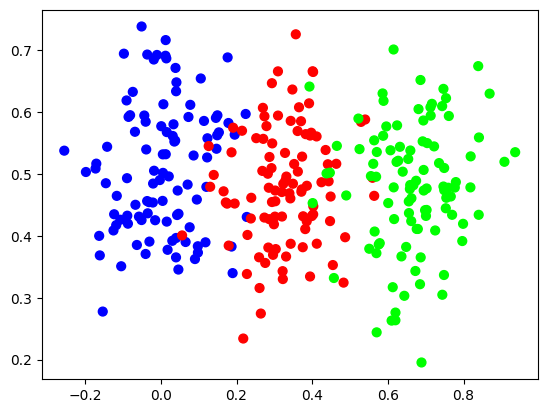

In [13]:
#loading a vertical dataset which is simple to optimize
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import vertical_data
nnfs.init()
X, y = vertical_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='brg')
plt.show()


# Gradient Calculation for a Single Neuron with 3 Inputs

This example explains the exact idea shown in the image.

The goal is to understand:

$$
\frac{\partial Loss}{\partial w_0}
$$

which means:

> "How much does the loss change if I slightly change weight \(w_0\)?"

This is exactly what Backpropagation computes.

---

# Step 1: The Single Neuron

Suppose we have:

```text
x0 = Input 0
x1 = Input 1
x2 = Input 2
```

and weights:

```text
w0
w1
w2
```

along with a bias:

```text
b
```

The neuron computes:

$$
z = x_0w_0 + x_1w_1 + x_2w_2 + b
$$

Diagram:

```text
x0 ----(w0)--\
              \
x1 ----(w1)----> SUM ---> z
              /
x2 ----(w2)--/
               + b
```

---

# Step 2: Apply ReLU

The neuron output becomes:

$$
a = ReLU(z)
$$

where:

$$
ReLU(z)=
\begin{cases}
z & z > 0\\
0 & z \le 0
\end{cases}
$$

Diagram:

```text
SUM
 ↓
ReLU
 ↓
Activation a
```

---

# Step 3: Compute Loss

Suppose our loss is:

$$
Loss = a^2
$$

Diagram:

```text
Inputs
   ↓
Weighted Sum
   ↓
ReLU
   ↓
Output a
   ↓
Loss = a²
```

---

# Writing Everything Together

Starting from inputs:

$$
Loss=
\Big(
ReLU(
x_0w_0+x_1w_1+x_2w_2+b
)
\Big)^2
$$

This is exactly what is shown in the image.

---

# The Problem

We want:

$$
\frac{\partial Loss}{\partial w_0}
$$

The loss depends on:

```text
Loss
 ↓
ReLU
 ↓
Sum
 ↓
Multiplication
 ↓
w0
```

Since multiple operations are connected together,

we must use the **Chain Rule**.

---

# Breaking the Computation into Pieces

Let

$$
m_0=x_0w_0
$$

$$
m_1=x_1w_1
$$

$$
m_2=x_2w_2
$$

Then

$$
s=m_0+m_1+m_2+b
$$

Then

$$
a=ReLU(s)
$$

Then

$$
Loss=a^2
$$

Computation graph:

```text
w0
 ↓
m0 = x0w0
 ↓
s = m0+m1+m2+b
 ↓
a = ReLU(s)
 ↓
Loss = a²
```

---

# Applying Chain Rule

The chain rule says:

$$
\frac{\partial Loss}{\partial w_0}
=
\frac{\partial Loss}{\partial a}
\times
\frac{\partial a}{\partial s}
\times
\frac{\partial s}{\partial m_0}
\times
\frac{\partial m_0}{\partial w_0}
$$

This is exactly what is shown in the image.

---

# First Derivative

## Loss = a²

$$
Loss=a^2
$$

Derivative:

$$
\frac{\partial Loss}{\partial a}
=
2a
$$

---

# Second Derivative

## a = ReLU(s)

For ReLU:

$$
ReLU(s)=s
\quad if \quad s>0
$$

Derivative:

$$
\frac{\partial a}{\partial s}
=
1
$$

when

$$
s>0
$$

and

$$
0
$$

when

$$
s\le0
$$

---

# Third Derivative

## Sum Node

$$
s=m_0+m_1+m_2+b
$$

Derivative:

$$
\frac{\partial s}{\partial m_0}
=
1
$$

because:

$$
\frac{d(x+y+z)}{dx}=1
$$

---

# Fourth Derivative

## Multiplication Node

$$
m_0=x_0w_0
$$

Derivative:

$$
\frac{\partial m_0}{\partial w_0}
=
x_0
$$

because:

$$
\frac{d(x_0w_0)}{dw_0}
=
x_0
$$

---

# Combining Everything

Substitute into Chain Rule:

$$
\frac{\partial Loss}{\partial w_0}
=
(2a)
\times
(1)
\times
(1)
\times
(x_0)
$$

Therefore:

$$
\boxed{
\frac{\partial Loss}{\partial w_0}
=
2ax_0
}
$$

for the active ReLU case.

---

# Numerical Example

Suppose:

$$
x_0=1
$$

$$
x_1=2
$$

$$
x_2=3
$$

Weights:

$$
w_0=0.5
$$

$$
w_1=0.2
$$

$$
w_2=0.1
$$

Bias:

$$
b=1
$$

---

# Forward Pass

Compute multiplications:

$$
m_0=1\times0.5=0.5
$$

$$
m_1=2\times0.2=0.4
$$

$$
m_2=3\times0.1=0.3
$$

---

Compute sum:

$$
s=0.5+0.4+0.3+1
$$

$$
s=2.2
$$

---

Apply ReLU:

$$
a=ReLU(2.2)
$$

$$
a=2.2
$$

---

Compute loss:

$$
Loss=(2.2)^2
$$

$$
Loss=4.84
$$

---

# Backward Pass

First derivative:

$$
\frac{\partial Loss}{\partial a}
=
2(2.2)
=
4.4
$$

---

ReLU derivative:

$$
\frac{\partial a}{\partial s}
=
1
$$

---

Sum derivative:

$$
\frac{\partial s}{\partial m_0}
=
1
$$

---

Multiply derivative:

$$
\frac{\partial m_0}{\partial w_0}
=
x_0
=
1
$$

---

Final Gradient

$$
\frac{\partial Loss}{\partial w_0}
=
4.4
\times
1
\times
1
\times
1
$$

$$
=
4.4
$$

---

# What Does This Gradient Mean?

We found:

$$
\frac{\partial Loss}{\partial w_0}=4.4
$$

Positive gradient means:

```text
Increasing w0
will increase the loss.
```

Therefore Gradient Descent moves in the opposite direction:

$$
w_0
=
w_0
-
LearningRate
\times
4.4
$$

---

# The Big Idea

Backpropagation simply does this repeatedly:

```text
Start at Loss
      ↓
Differentiate Loss
      ↓
Differentiate ReLU
      ↓
Differentiate Sum
      ↓
Differentiate Multiplication
      ↓
Reach Weight
```

For every weight in the network:

```text
w0
w1
w2
...
```

The Chain Rule connects all the local derivatives together and produces:

$$
\frac{\partial Loss}{\partial Weight}
$$

which Gradient Descent uses to update the weights and reduce the loss.

In [14]:
#according to our approach one randomly assigning the weights and biases to get optimized weights which is not going to work
# Create dataset
X, y = vertical_data(samples=100, classes=3)
# Create model
dense1 = Layer_Dense(2, 3) # first dense layer, 2 inputs
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3) # second dense layer, 3 inputs, 3 outputs
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoryCrossEntropy()

# Helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

for iteration in range(100000):
 # Generate a new set of weights for next iteration(random updates)
 dense1.weights = 0.05 * np.random.randn(2, 3)
 dense1.biases = 0.05 * np.random.randn(1, 3)
 dense2.weights = 0.05 * np.random.randn(3, 3)
 dense2.biases = 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of the training data through this layer
 dense1.forward(X)
 activation1.forward(dense1.output)
 dense2.forward(activation1.output)
 activation2.forward(dense2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # If loss is smaller - print and save weights and biases aside
 if loss < lowest_loss:
   print('New set of weights found, iteration:', iteration,'loss:', loss, 'acc:', accuracy)
   best_dense1_weights = dense1.weights.copy()
   best_dense1_biases = dense1.biases.copy()
   best_dense2_weights = dense2.weights.copy()
   best_dense2_biases = dense2.biases.copy()
   lowest_loss = loss


New set of weights found, iteration: 0 loss: 1.1016203 acc: 0.3333333333333333
New set of weights found, iteration: 1 loss: 1.1002508 acc: 0.3333333333333333
New set of weights found, iteration: 2 loss: 1.0992025 acc: 0.3333333333333333
New set of weights found, iteration: 3 loss: 1.0986239 acc: 0.3333333333333333
New set of weights found, iteration: 10 loss: 1.0984299 acc: 0.3333333333333333
New set of weights found, iteration: 22 loss: 1.0976521 acc: 0.36333333333333334


New set of weights found, iteration: 150 loss: 1.0974255 acc: 0.3333333333333333
New set of weights found, iteration: 874 loss: 1.0972673 acc: 0.3333333333333333
New set of weights found, iteration: 894 loss: 1.096895 acc: 0.3333333333333333
New set of weights found, iteration: 1036 loss: 1.0954281 acc: 0.3333333333333333
New set of weights found, iteration: 88633 loss: 1.0952065 acc: 0.3333333333333333


In [15]:
#now randomly updating the weights and bias without choosing them randomly 
# Create dataset
X, y = vertical_data(samples=100, classes=3)
# Create model
dense1 = Layer_Dense(2, 3) # first dense layer, 2 inputs
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3) # second dense layer, 3 inputs, 3 outputs
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoryCrossEntropy()
# Helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()
for iteration in range(10000):
 # Update weights with some small random values
 dense1.weights += 0.05 * np.random.randn(2, 3)
 dense1.biases += 0.05 * np.random.randn(1, 3)
 dense2.weights += 0.05 * np.random.randn(3, 3)
 dense2.biases += 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of our training data through this layer
 dense1.forward(X)
 activation1.forward(dense1.output)
 dense2.forward(activation1.output)
 activation2.forward(dense2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # If loss is smaller - print and save weights and biases aside
 if loss < lowest_loss:
  print('New set of weights found, iteration:', iteration,'loss:', loss, 'acc:', accuracy)
  best_dense1_weights = dense1.weights.copy()
  best_dense1_biases = dense1.biases.copy()
  best_dense2_weights = dense2.weights.copy()
  best_dense2_biases = dense2.biases.copy()
  lowest_loss = loss
 # Revert weights and biases
 else:
  dense1.weights = best_dense1_weights.copy()
  dense1.biases = best_dense1_biases.copy()
  dense2.weights = best_dense2_weights.copy()
  dense2.biases = best_dense2_biases.copy()


New set of weights found, iteration: 0 loss: 1.1008747 acc: 0.3333333333333333
New set of weights found, iteration: 3 loss: 1.1005715 acc: 0.3333333333333333
New set of weights found, iteration: 4 loss: 1.099462 acc: 0.3333333333333333
New set of weights found, iteration: 9 loss: 1.099436 acc: 0.3333333333333333
New set of weights found, iteration: 10 loss: 1.09855 acc: 0.3333333333333333
New set of weights found, iteration: 13 loss: 1.098517 acc: 0.3333333333333333
New set of weights found, iteration: 14 loss: 1.0938607 acc: 0.3333333333333333
New set of weights found, iteration: 15 loss: 1.0920315 acc: 0.3333333333333333
New set of weights found, iteration: 17 loss: 1.0913911 acc: 0.3333333333333333
New set of weights found, iteration: 19 loss: 1.0910357 acc: 0.3333333333333333
New set of weights found, iteration: 20 loss: 1.0898421 acc: 0.3333333333333333
New set of weights found, iteration: 21 loss: 1.0843327 acc: 0.3333333333333333
New set of weights found, iteration: 26 loss: 1.0

In [16]:
#but if we see the above approach does not work for spiral data 
# Create dataset
X, y = spiral_data(samples=100, classes=3)# Create model
dense1 = Layer_Dense(2, 3) # first dense layer, 2 inputs
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3) # second dense layer, 3 inputs, 3 outputs
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoryCrossEntropy()
# Helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()
for iteration in range(10000):
 # Update weights with some small random values
 dense1.weights += 0.05 * np.random.randn(2, 3)
 dense1.biases += 0.05 * np.random.randn(1, 3)
 dense2.weights += 0.05 * np.random.randn(3, 3)
 dense2.biases += 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of our training data through this layer
 dense1.forward(X)
 activation1.forward(dense1.output)
 dense2.forward(activation1.output)
 activation2.forward(dense2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # If loss is smaller - print and save weights and biases aside
 if loss < lowest_loss:
  print('New set of weights found, iteration:', iteration,'loss:', loss, 'acc:', accuracy)
  best_dense1_weights = dense1.weights.copy()
  best_dense1_biases = dense1.biases.copy()
  best_dense2_weights = dense2.weights.copy()
  best_dense2_biases = dense2.biases.copy()
  lowest_loss = loss
 # Revert weights and biases
 else:
  dense1.weights = best_dense1_weights.copy()
  dense1.biases = best_dense1_biases.copy()
  dense2.weights = best_dense2_weights.copy()
  dense2.biases = best_dense2_biases.copy()


New set of weights found, iteration: 0 loss: 1.0991904 acc: 0.3333333333333333
New set of weights found, iteration: 1 loss: 1.0988214 acc: 0.3333333333333333
New set of weights found, iteration: 6 loss: 1.0982754 acc: 0.3333333333333333
New set of weights found, iteration: 14 loss: 1.0978642 acc: 0.3333333333333333
New set of weights found, iteration: 23 loss: 1.0972557 acc: 0.35
New set of weights found, iteration: 37 loss: 1.0970367 acc: 0.35
New set of weights found, iteration: 40 loss: 1.0958394 acc: 0.37
New set of weights found, iteration: 41 loss: 1.0950066 acc: 0.4066666666666667
New set of weights found, iteration: 44 loss: 1.0948946 acc: 0.37333333333333335
New set of weights found, iteration: 53 loss: 1.0943341 acc: 0.3933333333333333
New set of weights found, iteration: 58 loss: 1.0942849 acc: 0.36666666666666664
New set of weights found, iteration: 59 loss: 1.0941793 acc: 0.35
New set of weights found, iteration: 60 loss: 1.0926698 acc: 0.38666666666666666
New set of weigh

In [17]:
#coding backpropagation for single neuron
import numpy as np

# Initial parameters
weights = np.array([-3.0, -1.0, 2.0])
bias = 1.0
inputs = np.array([1.0, -2.0, 3.0])
target_output = 0.0
learning_rate = 0.001

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1.0, 0.0)

for iteration in range(200):
    # Forward pass
    linear_output = np.dot(weights, inputs) + bias
    output = relu(linear_output)
    loss = (output - target_output) ** 2

    # Backward pass
    dloss_doutput = 2 * (output - target_output)
    doutput_dlinear = relu_derivative(linear_output)
    dlinear_dweights = inputs
    dlinear_dbias = 1.0

    dloss_dlinear = dloss_doutput * doutput_dlinear
    dloss_dweights = dloss_dlinear * dlinear_dweights
    dloss_dbias = dloss_dlinear * dlinear_dbias

    # Update weights and bias
    weights -= learning_rate * dloss_dweights
    bias -= learning_rate * dloss_dbias

    # Print the loss for this iteration
    print(f"Iteration {iteration + 1}, Loss: {loss}")

print("Final weights:", weights)
print("Final bias:", bias)


Iteration 1, Loss: 36.0
Iteration 2, Loss: 33.872397424621624
Iteration 3, Loss: 31.87054345809546
Iteration 4, Loss: 29.98699091998773
Iteration 5, Loss: 28.214761511794592
Iteration 6, Loss: 26.54726775906168
Iteration 7, Loss: 24.978326552541866
Iteration 8, Loss: 23.5021050739742
Iteration 9, Loss: 22.11313179151597
Iteration 10, Loss: 20.806246424284897
Iteration 11, Loss: 19.576596334671486
Iteration 12, Loss: 18.41961908608719
Iteration 13, Loss: 17.33101994032309
Iteration 14, Loss: 16.306757070164853
Iteration 15, Loss: 15.343027506224132
Iteration 16, Loss: 14.436253786815284
Iteration 17, Loss: 13.583071280700132
Iteration 18, Loss: 12.780312744165439
Iteration 19, Loss: 12.024995767388878
Iteration 20, Loss: 11.314319082257104
Iteration 21, Loss: 10.64564263994962
Iteration 22, Loss: 10.016485041642266
Iteration 23, Loss: 9.424510031713222
Iteration 24, Loss: 8.867521365009814
Iteration 25, Loss: 8.34345204094211
Iteration 26, Loss: 7.850353118483743
Iteration 27, Loss: 7.3

In [18]:
#coding backpropagation for layer of neurons 
import numpy as np

# Initial inputs
inputs = np.array([1, 2, 3, 4])

# Initial weights and biases
weights = np.array([
    [0.1, 0.2, 0.3, 0.4],
    [0.5, 0.6, 0.7, 0.8],
    [0.9, 1.0, 1.1, 1.2]
])

biases = np.array([0.1, 0.2, 0.3])

# Learning rate
learning_rate = 0.001

# ReLU activation function and its derivative
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Training loop
for iteration in range(200):
    # Forward pass
    z = np.dot(weights, inputs) + biases
    a = relu(z)
    y = np.sum(a)

    # Calculate loss
    loss = y ** 2

    # Backward pass
    # Gradient of loss with respect to output y
    dL_dy = 2 * y

    # Gradient of y with respect to a
    dy_da = np.ones_like(a)

    # Gradient of loss with respect to a
    dL_da = dL_dy * dy_da

    # Gradient of a with respect to z (ReLU derivative)
    da_dz = relu_derivative(z)

    # Gradient of loss with respect to z
    dL_dz = dL_da * da_dz

    # Gradient of z with respect to weights and biases
    dL_dW = np.outer(dL_dz, inputs)
    dL_db = dL_dz

    # Update weights and biases
    weights -= learning_rate * dL_dW
    biases -= learning_rate * dL_db

    # Print the loss every 20 iterations
    if iteration % 20 == 0:
        print(f"Iteration {iteration}, Loss: {loss}")

# Final weights and biases
print("Final weights:\n", weights)
print("Final biases:\n", biases)



Iteration 0, Loss: 466.56000000000006
Iteration 20, Loss: 5.329595763793193
Iteration 40, Loss: 0.41191524253483786
Iteration 60, Loss: 0.03183621475376345
Iteration 80, Loss: 0.002460565405431671
Iteration 100, Loss: 0.0001901729121621426
Iteration 120, Loss: 1.4698120139337557e-05
Iteration 140, Loss: 1.1359948840900371e-06
Iteration 160, Loss: 8.779778427447647e-08
Iteration 180, Loss: 6.785903626216421e-09
Final weights:
 [[-0.00698895 -0.0139779  -0.02096685 -0.0279558 ]
 [ 0.25975286  0.11950571 -0.02074143 -0.16098857]
 [ 0.53548461  0.27096922  0.00645383 -0.25806156]]
Final biases:
 [-0.00698895 -0.04024714 -0.06451539]


In [19]:
#coding backpropogation from scartch for a batch of inputs
#dweights derivative of loss with respect to weights dL/dz then *dz/dw
dvalues=np.array([[1,1,1],
                  [2,2,2],
                  [3,3,3]])
inputs=np.array([[1,2,3,2.5],
                [2,5,-1,2],
                [-1.5,2.8,3.3,-0.8]])
dweights=np.dot(inputs.T,dvalues)
biases=np.array([2,3,7])
dbiases=np.sum(dvalues,axis=0,keepdims=True)
print(dweights)
print(dbiases)

[[ 0.5  0.5  0.5]
 [20.4 20.4 20.4]
 [10.9 10.9 10.9]
 [ 4.1  4.1  4.1]]
[[6 6 6]]


In [20]:
#calculating the gradient of loss with respect to inputs
weights=np.array([[0.2,0.8,0.4,-0.7],
                  [0.3,0.5,-0.2,0.5],
                  [0.7,0.8,0.3,0.5]])
dinputs=np.dot(dvalues,weights)
print(dinputs)

[[1.2 2.1 0.5 0.3]
 [2.4 4.2 1.  0.6]
 [3.6 6.3 1.5 0.9]]
